In [ ]:
# Imports

import pickle
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import warnings
import sklearn
import cartopy.feature as cfeature
from shapely.geometry.polygon import LinearRing
import cartopy as ct
from sklearn import metrics
import xarray as xr

MODEL_DIRECTORY = "../../data/saved_models/"
PREDICTIONS_DIRECTORY = "../../data/saved_predictions/"
DATA_DIRECTORY = "../../data/splits"
DIAGNOSTICS_DIRECTORY = "../../data/model_diagnostics/"
FIGURES_DIRECTORY = "../../data/figures/"
NETCDF_DIRECTORY = "../../data/saved_netCDF/"

In [2]:
# CNN/file Functions

def get_settings(experiment_name):
    experiments = {
        "CanESM5_rsut": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.00005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(5).tolist(),
            "n_epochs": 5_000,
        },
        "CanESM5_rlut": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.00005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(5).tolist(),
            "n_epochs": 5_000,
        },
    }
    exp_dict = experiments[experiment_name]
    exp_dict['exp_name'] = experiment_name
    if 'n_train_val_test' in exp_dict.keys():
        exp_dict['n_members'] = int(np.sum(exp_dict["n_train_val_test"]))

    return exp_dict

def get_model_name(settings, suffix=""):
    model_name = (settings["exp_name"] + suffix + '_rngseed' + str(settings["rng_seed"]))
    return model_name

In [3]:
# Plotting utilities adapted from the CNN repository

# Matplotlib colors
npcols = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', 
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', 
]

warnings.filterwarnings("ignore")
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150

data_crs = ccrs.PlateCarree()
proj_Global = ccrs.EqualEarth(central_longitude=200)

"""
Functions
"""

def plot_metrics(history, metric):
    """
    history options: loss, val_loss, mae, val_mae
    
    Shows how the model improves during training.
    
    1. plot_metrics(history, 'loss')
    Shows mean squared error values for training loss and validation loss.
    Shows how close predicted values are to the actual values.

    2. plot_metrics(history, "mae")
    Mean absolute error in W/m^2.

    imin = epoch with lowest validation loss
    """
    imin = np.argmin(history.history['val_loss'])

    plt.plot(history.history[metric], label='training')
    plt.plot(history.history['val_' + metric], label='validation')
    plt.title(metric)
    plt.axvline(x=imin, linewidth=.5, color='gray', alpha=.5)
    plt.legend()

def plot_metrics_panels(history, predictions):
    # BASELINES TO BEAT
    baseline_mae = np.mean(np.abs(predictions["labels_test"] - 0.0))
    baseline_mse = np.mean((predictions["labels_test"] - 0.0)**2)

    # DO THE PLOTTING
    plt.subplots(figsize=(20, 4))

    plt.subplot(1, 4, 1)
    plot_metrics(history, 'loss')
    plt.ylim(0, .5)
    plt.axhline(y=baseline_mse, color="gray", linestyle="--", label="baseline")

    plt.subplot(1, 4, 2)
    plot_metrics(history, "mae")
    plt.ylim(0, .5)
    plt.axhline(y=baseline_mae, color="gray", linestyle="--", label="baseline")

    plt.legend()


def plot_pred_vs_truth(predictions, settings, ms=5, label=''):

    """
    Shows true CRE (x-axis) vs. predicted CRE (y-axis).
    A diagonal line represents be a perfect prediction.
    """

    mse = sklearn.metrics.mean_squared_error(predictions["labels_val"], predictions["pred_val"])
    if np.isnan(mse):
        mse = 0.
    plt.plot(predictions["labels_val"], predictions["pred_val"], '.', alpha=.5,
                label=label + ' (MSE=' + str(mse.round(3)) + ')', markersize=ms)

    plt.plot((-10, 10), (-10, 10), '--k', alpha=.5)
    plt.ylim(-8, 3)
    plt.xlim(-8, 3)
    plt.ylabel('predicted')
    plt.xlabel('truth')
    plt.legend(frameon=False, fontsize=8)
    plt.gca().set_aspect('equal')

def setup_figure(nCols=1,nRows=1,size=(15,15),mask=True):

    """
    This function makes sure that all plots we make have the same projection and layout.
    
    Example usage to make two maps:
    
    fig, ax = setup_figure(nCols=2, size=(12,5))

    ax[0].contourf(...)
    ax[1].contourf(...)
    """

    map_proj = proj_Global

    land_feature = cfeature.NaturalEarthFeature(

        #If mask = True, then the land will appear grey

        category='physical',
        name='land',
        scale='50m',
        facecolor='gray',
        edgecolor='k',
        linewidth=.25,
    )

    fig = plt.figure(figsize=size)
    if nCols==1 and nRows==1:

        """
        +----------------+
        |                |
        |   Global map   |
        |                |
        +----------------+
        """
        ax = fig.add_subplot(1, 1, 1, projection=map_proj)

        ax.coastlines('50m', linewidth=0.8)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.gridlines(
            draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
        )

        if mask:
            ax.add_feature(land_feature)
    elif nCols > 1 and nRows > 1:
        
        """
        +---------+---------+
        | map 1   | map 2   |
        +---------+---------+
        | map 3   | map 4   |
        +---------+---------+
        """
        ax = np.empty((nCols,nRows),dtype=object)
        iF = 1
        for jj in range(nRows):
            for ii in range(nCols):
                ax[ii,jj] = fig.add_subplot(nRows, nCols, iF, projection=map_proj)

                ax[ii,jj].coastlines('50m', linewidth=0.8)
                ax[ii,jj].tick_params(axis='both', which='major', labelsize=10)
                ax[ii,jj].gridlines(
                    draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
                )
                if mask:
                    ax[ii,jj].add_feature(land_feature)
                iF += 1
    elif nCols > 1:
        """
        +-------+-------+-------+
        | map1  | map2  | map3  |
        +-------+-------+-------+
        """
        ax = np.empty((nCols),dtype=object)
        for ii in range(nCols):
            ax[ii] = fig.add_subplot(1, nCols, ii+1, projection=map_proj)

            ax[ii].coastlines('50m', linewidth=0.8)
            ax[ii].tick_params(axis='both', which='major', labelsize=10)
            ax[ii].gridlines(
                draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
            )
            if mask:
                ax[ii].add_feature(land_feature)
    elif nRows > 1:
        """
        +-------+
        | map1  |
        +-------+
        | map2  |
        +-------+
        | map3  |
        +-------+
        """
        ax = np.empty((nRows),dtype=object)
        for ii in range(nRows):
            ax[ii] = fig.add_subplot(nRows, 1, ii+1, projection=map_proj)

            ax[ii].coastlines('50m', linewidth=0.8)
            ax[ii].tick_params(axis='both', which='major', labelsize=10)
            ax[ii].gridlines(
                draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
            )
            if mask:
                ax[ii].add_feature(land_feature)

            
    return fig, ax

def add_mask(ax,region,lon=None,lat=None):
    
    """
    Adds a mask for all land, a predefined region, or from a mask
    stored in a NetCDF file
    """

    if region == "land":
        land_feature = cfeature.NaturalEarthFeature(
            category='physical',
            name='land',
            scale='50m',
            facecolor='gray',
            edgecolor='k',
            linewidth=.25,
        )
        ax.add_feature(land_feature)
    elif region[:4] == "reg_":

        regions_range_dict = regions.get_region_dict(region)

        min_lon, max_lon = regions_range_dict["lon_range"]
        min_lat, max_lat = regions_range_dict["lat_range"]
        region = [min_lon, min_lat, max_lon, max_lat]

        add_square(ax,region,data_crs,facecolor='gray')

    elif region[-3:] == ".nc":

        mask = xr.load_dataarray(SHAPE_DIRECTORY + region).to_numpy()

        mask[mask>0.5] = np.nan
        mask_cyc, lons_cyc = add_cyclic_point(mask, coord=lon)
        ax.pcolormesh(lons_cyc,lat,mask_cyc,cmap="gray")

    return ax

def add_square(ax,region,crs,**kwargs):
    # Region = lon1, lat1; lon2, lat2

    """
    Example:
    +----------------------+
    |                      |
    |      ┌─────────┐     |
    |      │ region  │     |
    |      └─────────┘     |
    |                      |
    +----------------------+
    """

    lons = [region[0],region[2],region[2],region[0]]
    lats = [region[1],region[1],region[3],region[3]]
    ring = LinearRing(list(zip(lons,lats)))

    ax.add_geometries([ring],crs,**kwargs)

    return ax


def add_loc_square(ax,settings,**kwargs):
    """
    Use this to add a rectangle to a region without
    having to put in specific coordinates
    """
    if "mask_region" in settings.keys():
        maskout=settings["mask_region"]
    else:
        return ax

    if maskout == "indonesia":
        min_lon, max_lon = 75., 130.
        min_lat, max_lat = -15., 10.
    elif maskout == "westpacific":
        min_lon, max_lon = 170., 230.
        min_lat, max_lat = -30., -5.
    elif maskout == "eastpacific":
        min_lon, max_lon = 210., 280.
        min_lat, max_lat = -10., 10.
    elif maskout == "caribbean":
        min_lon, max_lon = 250., 320.
        min_lat, max_lat = 5., 25.
    elif maskout == "brazil":
        min_lon, max_lon = 310., 350.
        min_lat, max_lat = -25., -5.
    elif maskout == "namibia":
        min_lon, max_lon = 0., 20.
        min_lat, max_lat = -45., -10.
    else:
        raise NotImplementedError("no such mask type.")
    
    if min_lon > 180 and max_lon > 180:
        min_lon = min_lon - 360
        max_lon = max_lon - 360
    
    add_square(ax,[min_lon,min_lat,max_lon,max_lat],data_crs,**kwargs)

    return ax

def round_to_n(x,n):
    """
    Round to significant digits instead of decimal places
    """
    if x == 0:
        return x
    else:
        return np.round(x, -int(np.floor(np.log10(abs(x)))) + (n - 1))
    
def num_lab(x,n):
    """ Converts a number to a string label """
    return str(round_to_n(x,n))

def get_area(lat,lon,mask=None):
    """
    Computes weights for each map cell based off of
    where it is on the globe (Since higher latitude cells will
    appear larger on a map plot then they are in actuality)
    
    Example:
    
    weights = get_area(lat, lon)

    global_mean = np.sum(weights * sst)
    
    will give a proper area-weighted global mean.
    """
    _, Y = np.meshgrid(lon,lat)

    dy = np.deg2rad(np.diff(lat)[0])
    dx = np.deg2rad(np.diff(lon)[0]) * np.cos(np.deg2rad(Y))

    area = dy * dx

    if mask is not None:
        area = area * mask
        area[np.isnan(area)] = 0.

    return area/np.sum(area)

In [4]:
# Load spatial grid
ds = xr.open_dataset(DATA_DIRECTORY + "/X_test.nc")

lat = ds["lat"].values
lon = ds["lon"].values
map_shape = (len(lat), len(lon))

ds.close()

In [5]:
sw_preds_all = []
lw_preds_all = []

for seed in range(5):

    sw_settings = get_settings("CanESM5_rsut")
    sw_settings["rng_seed"] = seed
    sw_model = get_model_name(sw_settings)

    with open(PREDICTIONS_DIRECTORY + sw_model + "_predictions.pickle", "rb") as f:
        sw_preds_all.append(pickle.load(f))


    lw_settings = get_settings("CanESM5_rlut")
    lw_settings["rng_seed"] = seed
    lw_model = get_model_name(lw_settings)

    with open(PREDICTIONS_DIRECTORY + lw_model + "_predictions.pickle", "rb") as f:
        lw_preds_all.append(pickle.load(f))

# prediction - truth (mean error maps)

sw_truth = sw_preds_all[0]["labels_test"]   # same across seeds
lw_truth = lw_preds_all[0]["labels_test"]

sw_pred_mean = np.mean(
    [p["pred_test"] for p in sw_preds_all], axis=0
)

lw_pred_mean = np.mean(
    [p["pred_test"] for p in lw_preds_all], axis=0
)

# Compute ensemble errors
sw_error = sw_pred_mean - sw_truth
lw_error = lw_pred_mean - lw_truth

# Mean error across test samples
sw_error_mean = np.mean(sw_error, axis=0)
lw_error_mean = np.mean(lw_error, axis=0)

# Reshape to maps
sw_error_map = sw_error_mean.reshape(map_shape)
lw_error_map = lw_error_mean.reshape(map_shape)

print(sw_error_map.shape)
print(lw_error_map.shape)
# expected output: (64, 128) (64, 128)

(64, 128)
(64, 128)


In [6]:
print(sw_preds_all[0].keys())
print(lw_preds_all[0].keys())

dict_keys(['labels_train', 'pred_train', 'labels_val', 'pred_val', 'labels_test', 'pred_test'])
dict_keys(['labels_train', 'pred_train', 'labels_val', 'pred_val', 'labels_test', 'pred_test'])


In [8]:
# Compute ensemble errors
abs_sw_error_map = abs(sw_error_map)
abs_lw_error_map = abs(lw_error_map)

print(abs_sw_error_map.shape)
print(abs_lw_error_map.shape)

(64, 128)
(64, 128)


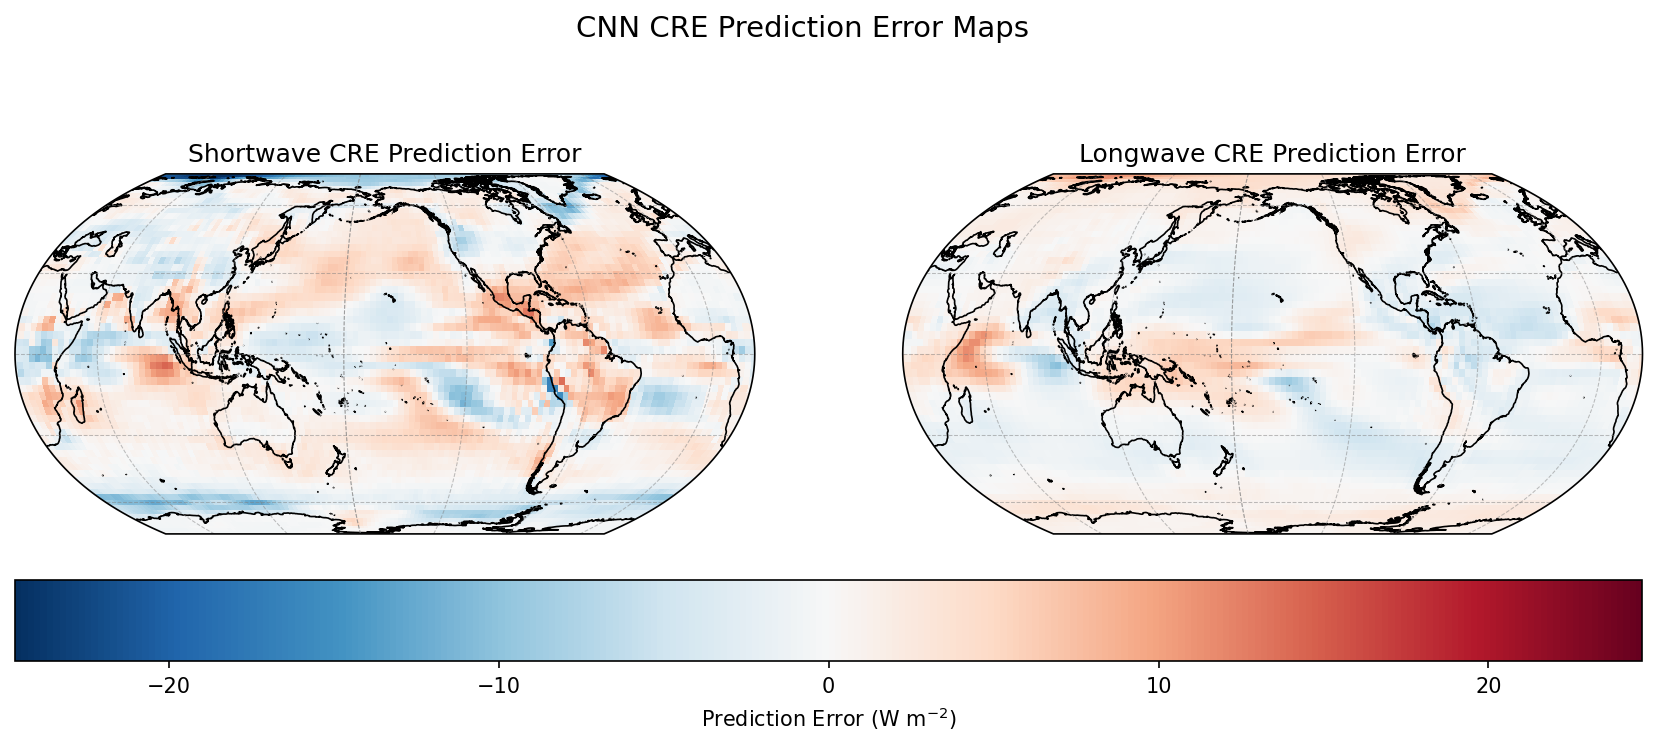

In [9]:
# Plot SW vs LW CRE error maps

fig, ax = setup_figure(nCols=2, nRows=1, size=(14,5), mask=False)

vmax = np.nanmax(np.abs([sw_error_map, lw_error_map]))

# ---- Shortwave error ----
pcm0 = ax[0].pcolormesh(
    lon,
    lat,
    sw_error_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=data_crs
)

ax[0].set_title("Shortwave CRE Prediction Error")

# ---- Longwave error ----
pcm1 = ax[1].pcolormesh(
    lon,
    lat,
    lw_error_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=data_crs
)

ax[1].set_title("Longwave CRE Prediction Error")

# Colorbar
cbar = plt.colorbar(pcm1, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Prediction Error (W m$^{-2}$)")

plt.suptitle("CNN CRE Prediction Error Maps", fontsize=14)

plt.show()

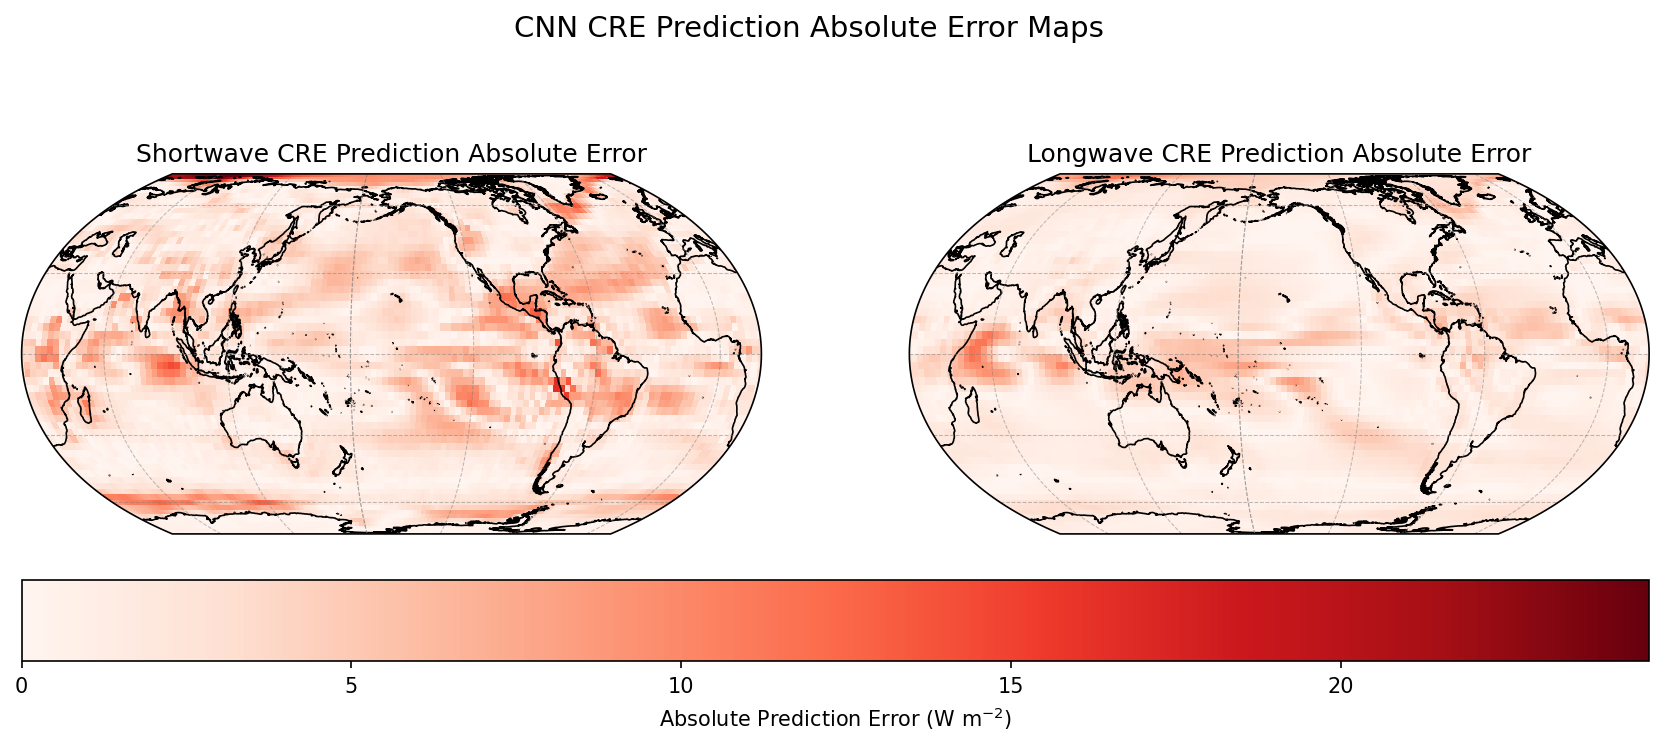

In [30]:
# plot absolute errors – values are all positive so use a sequential colormap
fig, ax = setup_figure(nCols=2, nRows=1, size=(14,5), mask=False)

vmax = np.nanmax(np.abs([abs_sw_error_map, abs_lw_error_map]))

cmap = "Reds"   # could also be "viridis", "magma", …

# ---- Shortwave absolute error ----
pcm0 = ax[0].pcolormesh(
    lon, lat, abs_sw_error_map,
    cmap=cmap,
    vmin=0, vmax=vmax,
    transform=data_crs
)
ax[0].set_title("Shortwave CRE Prediction Absolute Error")

# ---- Longwave absolute error ----
pcm1 = ax[1].pcolormesh(
    lon, lat, abs_lw_error_map,
    cmap=cmap,
    vmin=0, vmax=vmax,
    transform=data_crs
)
ax[1].set_title("Longwave CRE Prediction Absolute Error")

# colourbar – already starts at zero because of vmin
cbar = plt.colorbar(pcm1, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Absolute Prediction Error (W m$^{-2}$)")

plt.suptitle("CNN CRE Prediction Absolute Error Maps", fontsize=14)
plt.show()


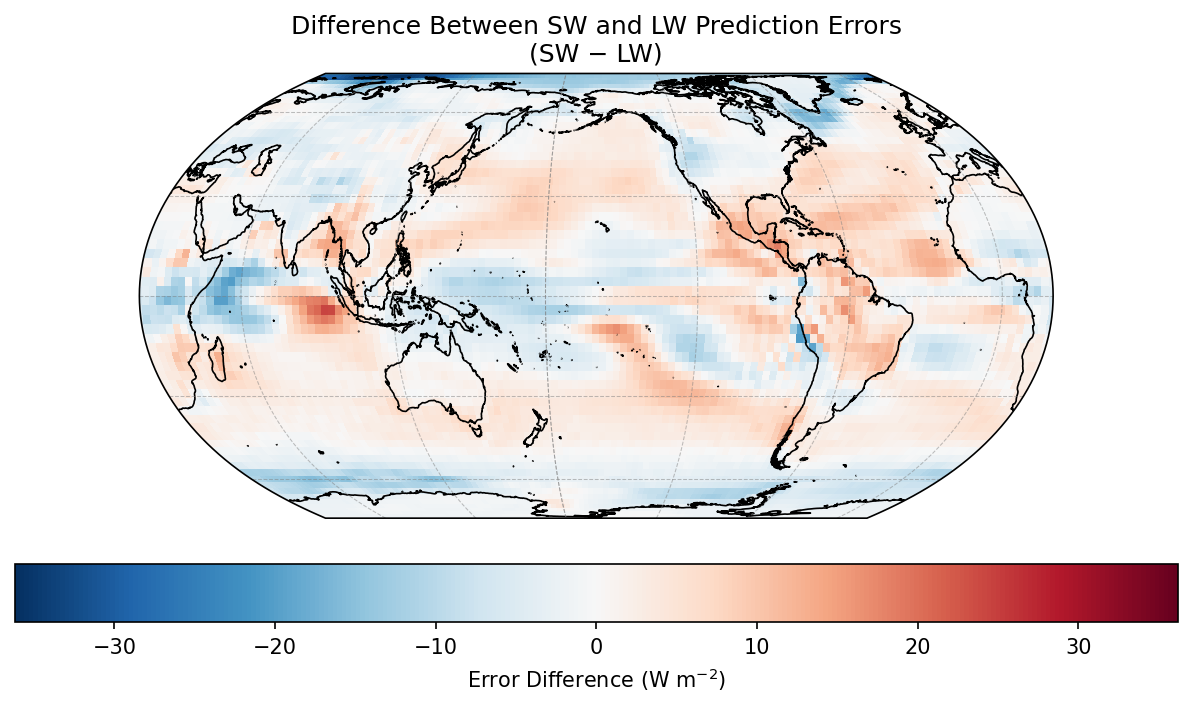

In [11]:
# Compute difference between SW and LW model errors

error_diff_map = sw_error_map - lw_error_map


fig, ax = setup_figure(size=(10,5), mask=False)

vmax = np.nanmax(np.abs(error_diff_map))

pcm = ax.pcolormesh(
    lon,
    lat,
    error_diff_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=data_crs
)

ax.set_title("Difference Between SW and LW Prediction Errors\n(SW − LW)")

cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Error Difference (W m$^{-2}$)")

plt.show()

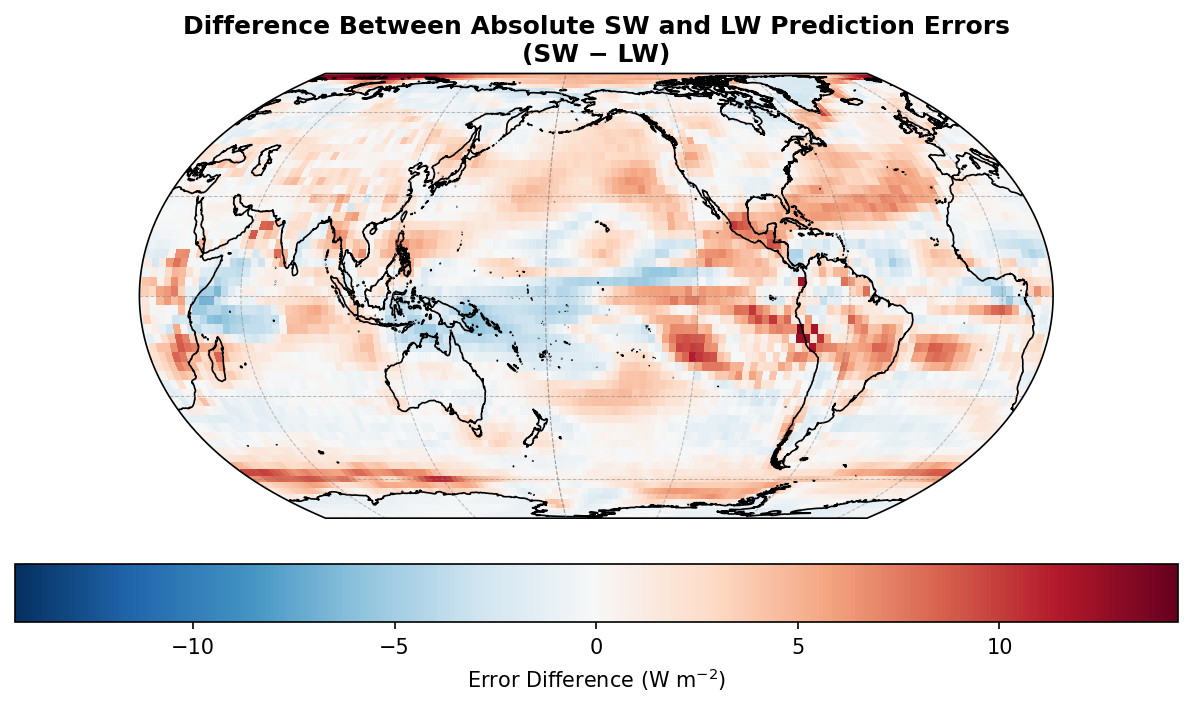

In [59]:
# Compute difference between absolute SW and LW model errors

error_diff_map = abs_sw_error_map - abs_lw_error_map


fig, ax = setup_figure(size=(10,5), mask=False)

vmax = np.nanmax(np.abs(error_diff_map))

pcm = ax.pcolormesh(
    lon,
    lat,
    error_diff_map,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    transform=data_crs
)

ax.set_title("Difference Between Absolute SW and LW Prediction Errors\n(SW − LW)")

cbar = plt.colorbar(pcm, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Error Difference (W m$^{-2}$)")

plt.rcParams["axes.titleweight"] = "bold"
plt.show()

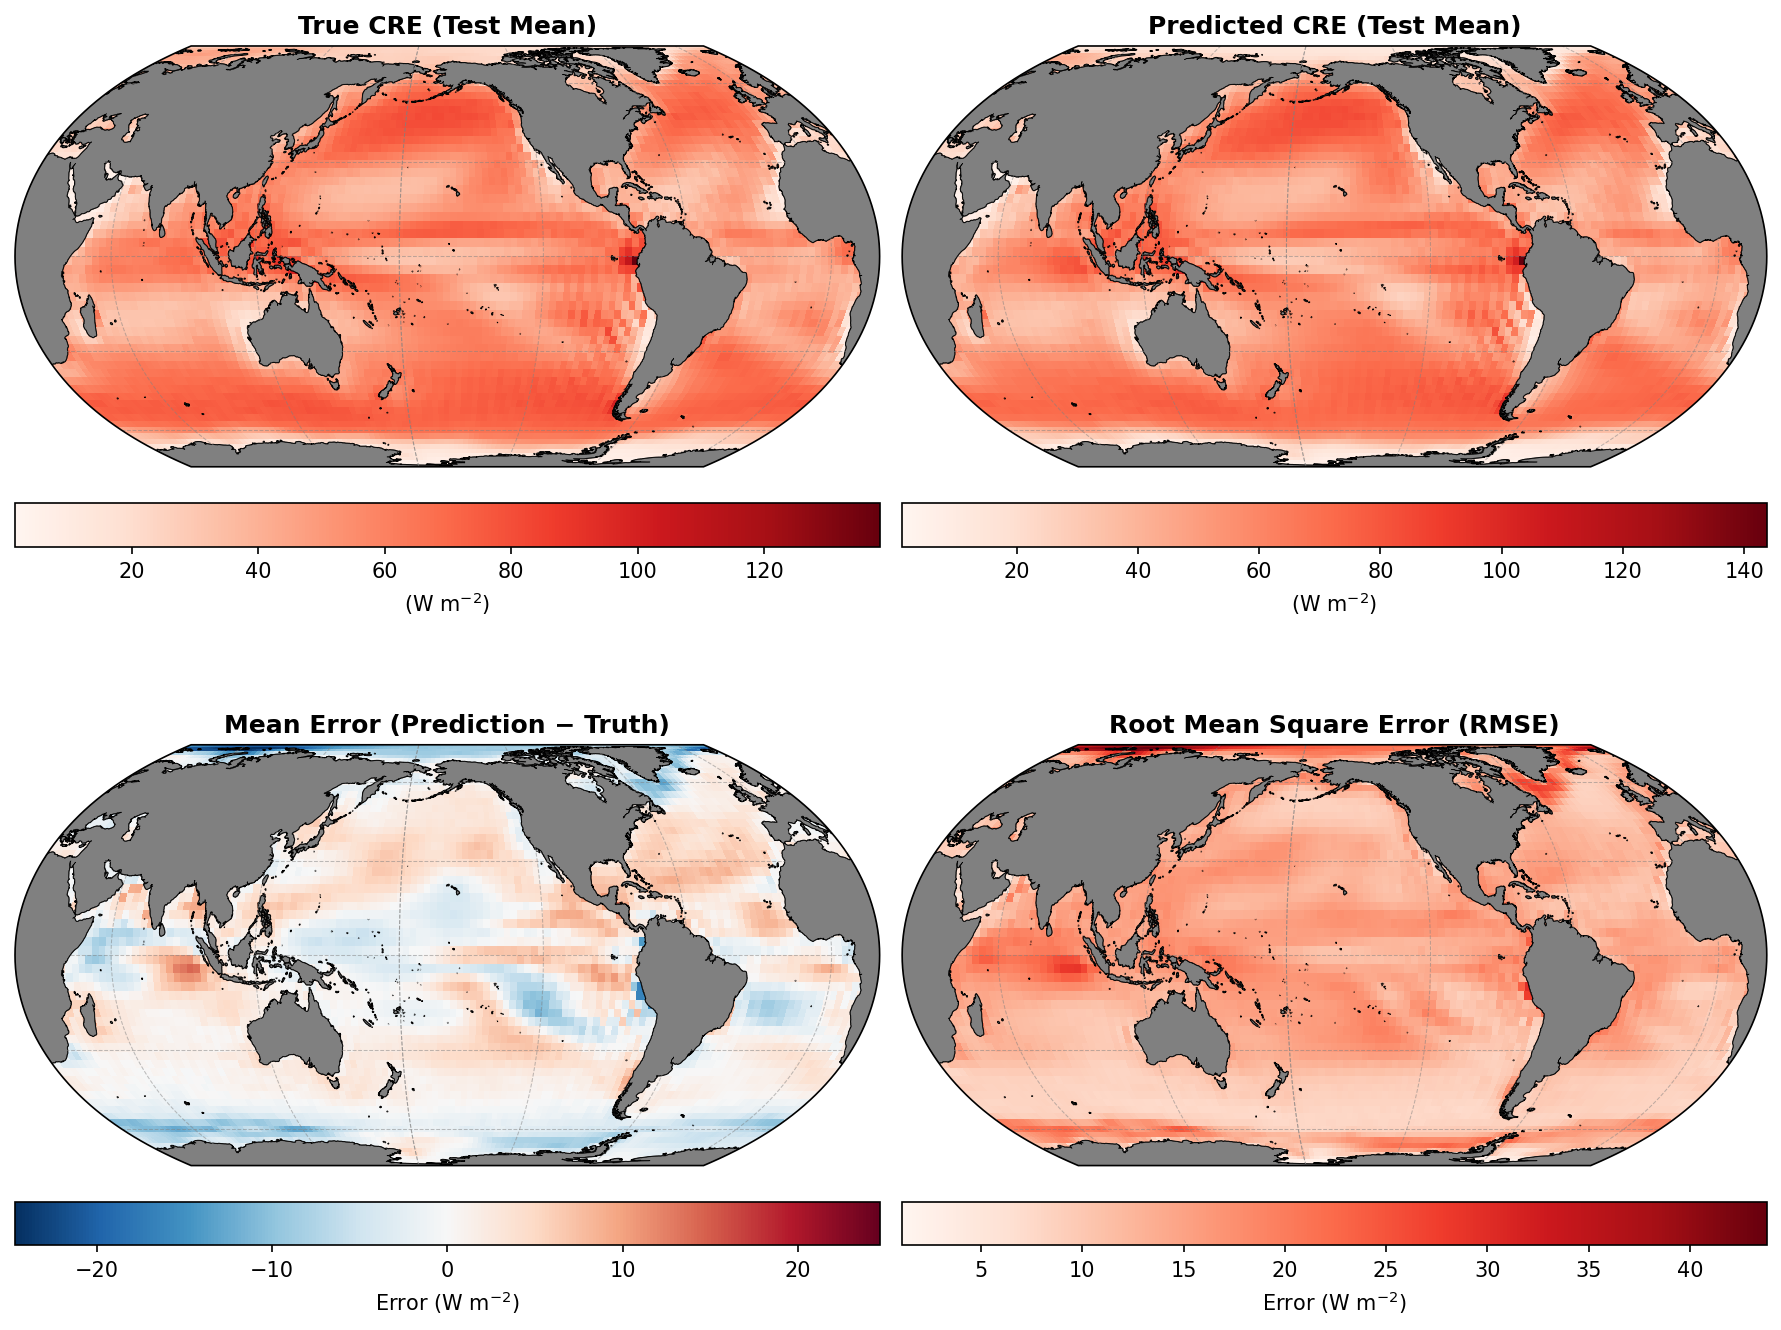

In [58]:
# Draft of 4-panel output figure, showing true values, predicted values, and then comparing them. Can make one figure for either LW or SW

# Select prediction set

# Extract data (or sw_pred_mean)
pred = sw_pred_mean
truth = sw_truth

# Compute statistics
truth_mean = np.mean(truth, axis=0)
pred_mean  = np.mean(pred, axis=0)

error = pred - truth
error_mean = np.mean(error, axis=0)

cmap="Reds"

rmse = np.sqrt(np.mean(error**2, axis=0))

# Reshape to spatial maps
truth_map = truth_mean.reshape(map_shape)
pred_map  = pred_mean.reshape(map_shape)
error_map = error_mean.reshape(map_shape)
rmse_map  = rmse.reshape(map_shape)

# Create figure
fig, ax = setup_figure(nCols=2, nRows=2, size=(12,10))

# Panel 1: True values
im0 = ax[0,0].pcolormesh(lon, lat, truth_map,
                         cmap=cmap,
                         transform=data_crs)
ax[0,0].set_title("True CRE (Test Mean)")
plt.colorbar(im0, ax=ax[0,0], orientation="horizontal", pad=0.05, label="(W m$^{-2}$)")

# Panel 2: Predicted values
im1 = ax[1,0].pcolormesh(lon, lat, pred_map, cmap=cmap,
                         transform=data_crs)
ax[1,0].set_title("Predicted CRE (Test Mean)")
plt.colorbar(im1, ax=ax[1,0], orientation="horizontal", pad=0.05, label="(W m$^{-2}$)")

# Panel 3: Mean Error
# force the colour scale to be symmetric about zero so that 0 falls
# in the centre of the RdBu_r map (white)
vmax_err = np.nanmax(np.abs(error_map))
im2 = ax[0,1].pcolormesh(lon, lat, error_map, cmap="RdBu_r",
                         vmin=-vmax_err, vmax=vmax_err,
                         transform=data_crs)
ax[0,1].set_title("Mean Error (Prediction − Truth)")
plt.colorbar(im2, ax=ax[0,1], orientation="horizontal", pad=0.05, label="Error (W m$^{-2}$)")

# Panel 4: RMSE
im3 = ax[1,1].pcolormesh(lon, lat, rmse_map, cmap="Reds",
                         transform=data_crs)
ax[1,1].set_title("Root Mean Square Error (RMSE)")
plt.colorbar(im3, ax=ax[1,1], orientation="horizontal", pad=0.05, label="Error (W m$^{-2}$)")

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
plt.tight_layout()
plt.show()

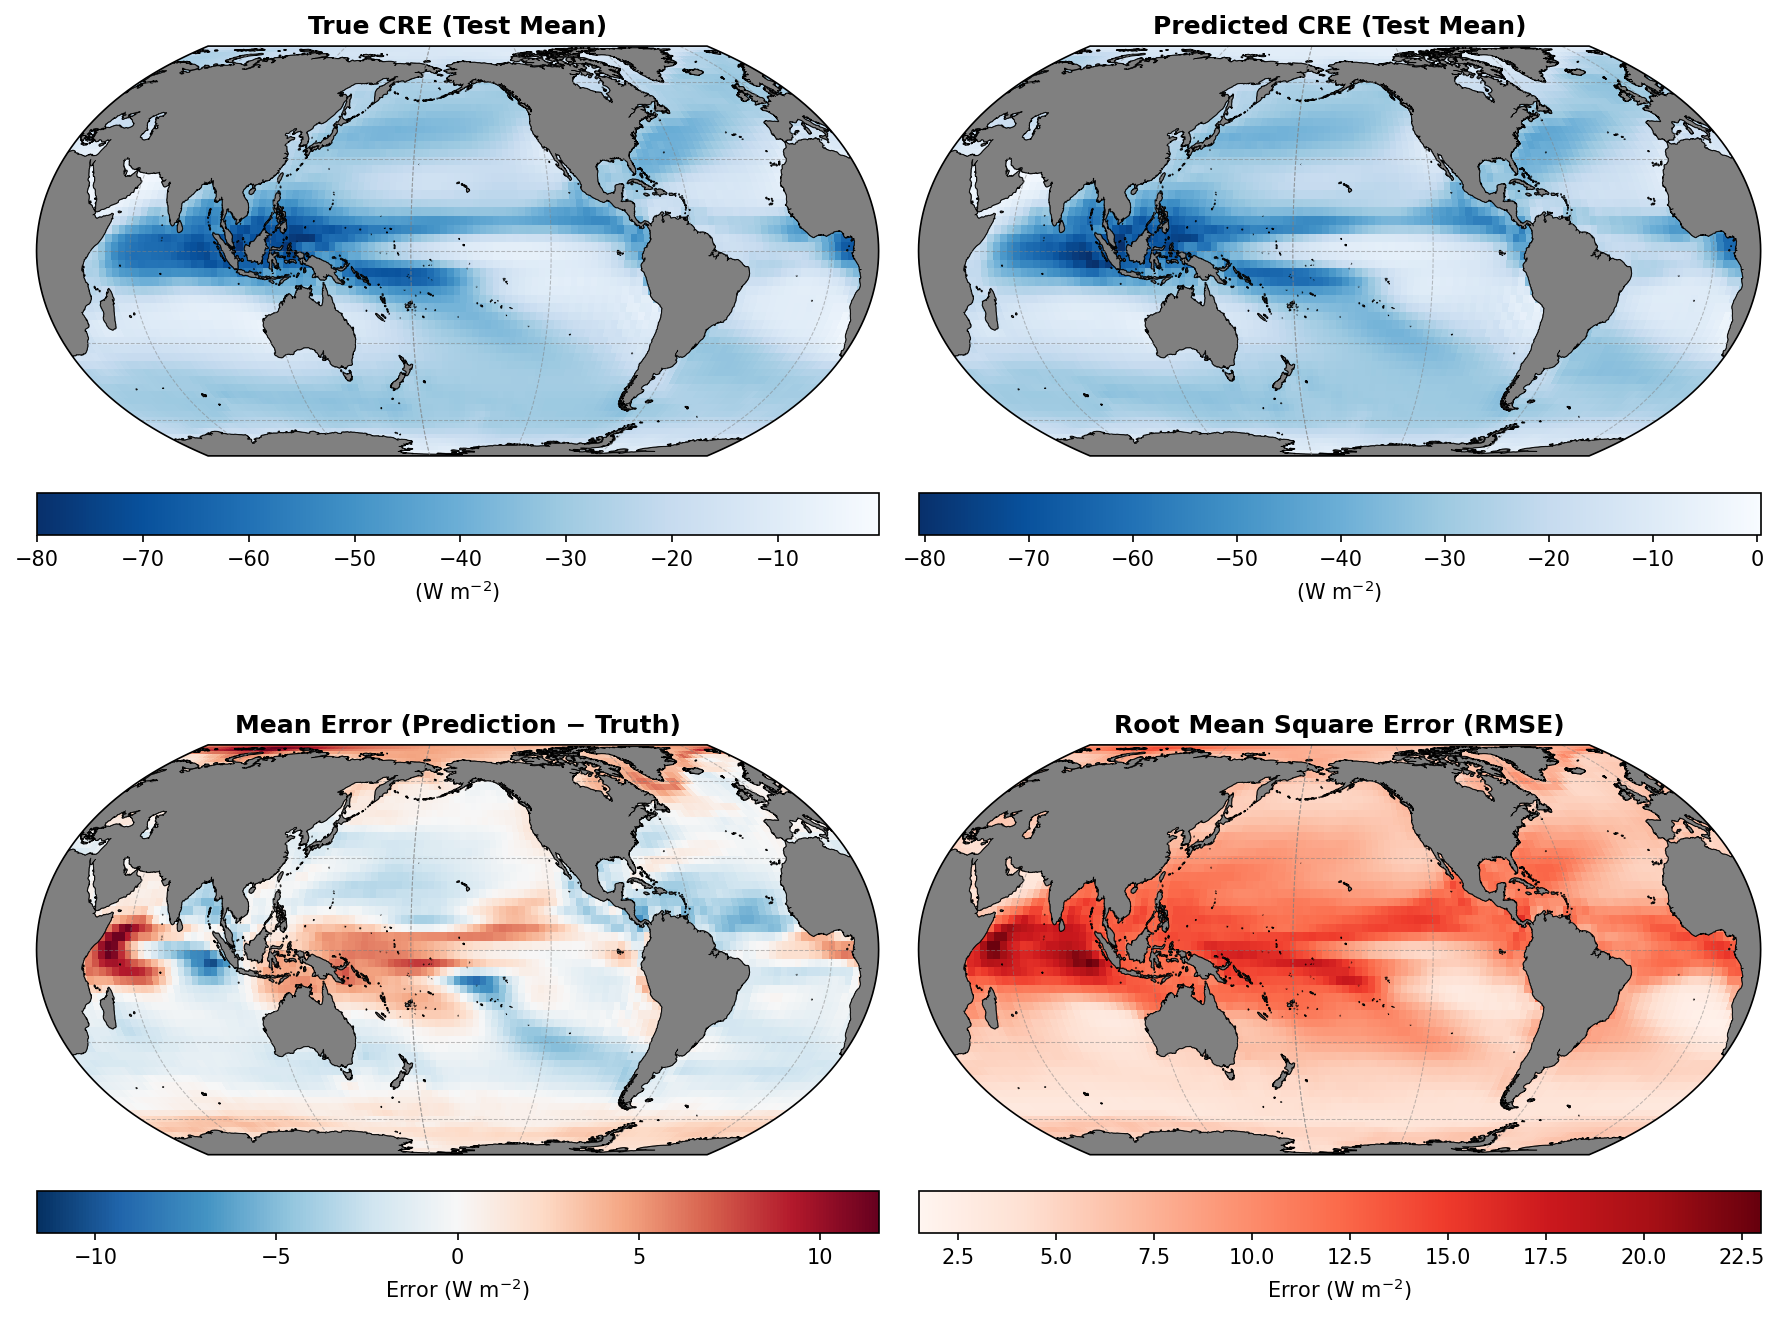

In [57]:
# Draft of 4-panel output figure, showing true values, predicted values, and then comparing them. Can make one figure for either LW or SW

# Select prediction set

# Extract data (or sw_pred_mean)
pred = lw_pred_mean
truth = lw_truth

# Compute statistics
truth_mean = np.mean(truth, axis=0)
pred_mean  = np.mean(pred, axis=0)

error = pred - truth
error_mean = np.mean(error, axis=0)

cmap="Blues_r"

rmse = np.sqrt(np.mean(error**2, axis=0))

# Reshape to spatial maps
truth_map = truth_mean.reshape(map_shape)
pred_map  = pred_mean.reshape(map_shape)
error_map = error_mean.reshape(map_shape)
rmse_map  = rmse.reshape(map_shape)

# Create figure
fig, ax = setup_figure(nCols=2, nRows=2, size=(12,10))

# Panel 1: True values
im0 = ax[0,0].pcolormesh(lon, lat, truth_map,
                         cmap=cmap,
                         transform=data_crs)
ax[0,0].set_title("True CRE (Test Mean)")
plt.colorbar(im0, ax=ax[0,0], orientation="horizontal", pad=0.05, label="(W m$^{-2}$)")

# Panel 2: Predicted values
im1 = ax[1,0].pcolormesh(lon, lat, pred_map, cmap=cmap,
                         transform=data_crs)
ax[1,0].set_title("Predicted CRE (Test Mean)")
plt.colorbar(im1, ax=ax[1,0], orientation="horizontal", pad=0.05, label="(W m$^{-2}$)")

# Panel 3: Mean Error
# force the colour scale to be symmetric about zero so that 0 falls
# in the centre of the RdBu_r map (white)
vmax_err = np.nanmax(np.abs(error_map))
im2 = ax[0,1].pcolormesh(lon, lat, error_map, cmap="RdBu_r",
                         vmin=-vmax_err, vmax=vmax_err,
                         transform=data_crs)
ax[0,1].set_title("Mean Error (Prediction − Truth)")
plt.colorbar(im2, ax=ax[0,1], orientation="horizontal", pad=0.05, label="Error (W m$^{-2}$)")

# Panel 4: RMSE
im3 = ax[1,1].pcolormesh(lon, lat, rmse_map, cmap="Reds",
                         transform=data_crs)
ax[1,1].set_title("Root Mean Square Error (RMSE)")
plt.colorbar(im3, ax=ax[1,1], orientation="horizontal", pad=0.05, label="Error (W m$^{-2}$)")

#plt.suptitle("Summary of Longwave CRE", fontsize=14)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
plt.tight_layout()
plt.show()